<a href="https://colab.research.google.com/github/effiompraise/ATF-AI-Technical-School/blob/main/Week2_07_context_window_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2.2: Context Window Management

## Key Insight
> **Why can't you just paste a 500-page book into the prompt?**

## Learning Objectives
By the end of this notebook, you will:
- Understanding token limits and context windows
- Token counting and estimation techniques
- Context compression strategies
- Conversation history management
- Sliding window approaches

## Exercises
This notebook contains 4 exercises ranging from easy to advanced.

## Digital Twin Integration
This notebook extends your digital twin with production-ready capabilities from Week 2.

In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any, Tuple
import re
import json

print('✅ Week 2.2: Context Window Management - Ready to start!')
print('\nTopics covered:')
print('  - Understanding token limits and context windows')
print('  - Token counting and estimation techniques')
print('  - Context compression strategies')
print('  - Conversation history management')
print('  - Sliding window approaches')


✅ Week 2.2: Context Window Management - Ready to start!

Topics covered:
  - Understanding token limits and context windows
  - Token counting and estimation techniques
  - Context compression strategies
  - Conversation history management
  - Sliding window approaches


---
## Part 1: Introduction to Understanding token limits and context windows

Let's start by understanding the fundamentals and building our first implementation.

In [2]:
# Example implementation
# This is a starter template - expand with your implementation

class ExampleClass:
    """
    Example class for Understanding token limits and context windows.
    """

    def __init__(self):
        self.data = []

    def process(self, input_data):
        """
        Process the input data.
        """
        # Add your implementation here
        return input_data

# Test the class
example = ExampleClass()
result = example.process('test data')
print(f'Result: {result}')

Result: test data


### 🎯 Exercise 1 (Easy): Getting Started

**Task**: Implement a basic version of the concept introduced above.

**Requirements**:
1. Follow the pattern shown in the example
2. Test your implementation with sample data
3. Verify the output matches expectations
4. Add error handling for edge cases

In [3]:
class ContextWindow:
    """
    Example class for understanding token limits and context windows.
    Uses a simple word count to estimate 'tokens' and slides the window
    if the limit is exceeded.
    """

    def __init__(self, max_tokens: int = 10):
        # Initialisation: Validate the input to ensure max_tokens is a positive whole number.
        # This prevents errors later in the programme.
        if not isinstance(max_tokens, int) or max_tokens <= 0:
            raise ValueError("max_tokens must be a positive integer.")

        # Store the maximum allowed tokens for this context window limit
        self.max_tokens = max_tokens
        # Create an empty list to store our conversation history
        self.data = []
        # Keep a running tally of how many tokens are currently in the window
        self.current_tokens = 0

    def process(self, input_data: str) -> list:
        """
        Process the input text, add it to the context, and enforce the window limit.
        """
        # Defensive Programming Check 1: Ensure the user actually passed a string.
        if not isinstance(input_data, str):
            raise TypeError(f"Expected a string, but received {type(input_data).__name__}.")

        # Defensive Programming Check 2: Ensure the string isn't just empty spaces.
        if not input_data.strip():
            raise ValueError("Input data cannot be empty.")

        # Simple Token Estimation: Split the string by spaces to count the words.
        # (Real LLMs use complex tokenisers, but this simple proxy works for our exercise).
        new_tokens = len(input_data.split())

        # Boundary Check: If one message is bigger than the whole window, it can never fit.
        if new_tokens > self.max_tokens:
            raise ValueError("Single input exceeds the entire context window capacity.")

        # Add the new message to our list and update our running token tally.
        self.data.append(input_data)
        self.current_tokens += new_tokens

        # The Sliding Window Mechanism:
        # If our current tokens exceed our limit, we must loop through and drop
        # the oldest messages until we are back under the limit.
        while self.current_tokens > self.max_tokens:
            # .pop(0) removes and returns the first (oldest) item in the list.
            removed_text = self.data.pop(0)
            # Subtract the tokens of the removed text from our running tally.
            self.current_tokens -= len(removed_text.split())
            # Print a helpful message so we can see the sliding window in action.
            print(f"  [Context Window Full] Dropping oldest entry: '{removed_text}'")

        # Return the updated, perfectly sized list of messages to be sent to an LLM.
        return self.data

# --- Testing the Implementation ---
print("--- Initialising Context Window (Max 10 'tokens') ---")
window = ContextWindow(max_tokens=10)

try:
    # Test 1: Basic insertion (5 tokens)
    result1 = window.process("Hello, this is a test.")
    print(f"Result 1: {result1} (Current tokens: {window.current_tokens})")

    # Test 2: Fitting within the remaining window (3 tokens) - Total 8/10 tokens
    result2 = window.process("Adding more data.")
    print(f"Result 2: {result2} (Current tokens: {window.current_tokens})")

    # Test 3: Exceeding the window (7 tokens) - Total 15/10 tokens.
    # This will trigger the sliding window to drop the oldest data!
    print("\n--- Triggering Sliding Window ---")
    result3 = window.process("This will push out the oldest data.")
    print(f"Result 3: {result3} (Current tokens: {window.current_tokens})")

    # Test 4: Testing our error handling by passing an invalid type (integer instead of string)
    print("\n--- Testing Error Handling ---")
    window.process(12345)

except Exception as e:
    # Catch and print any errors so the programme doesn't just crash silently.
    print(f"Error caught: {e}")

--- Initialising Context Window (Max 10 'tokens') ---
Result 1: ['Hello, this is a test.'] (Current tokens: 5)
Result 2: ['Hello, this is a test.', 'Adding more data.'] (Current tokens: 8)

--- Triggering Sliding Window ---
  [Context Window Full] Dropping oldest entry: 'Hello, this is a test.'
Result 3: ['Adding more data.', 'This will push out the oldest data.'] (Current tokens: 10)

--- Testing Error Handling ---
Error caught: Expected a string, but received int.


---
## Part 2: Token counting and estimation techniques

Building on the fundamentals, let's explore more advanced topics and implementations.

In [4]:
# Advanced implementation example

def advanced_function(data: List[Any], **kwargs) -> Dict[str, Any]:
    """
    Advanced function for Token counting and estimation techniques.

    Args:
        data: Input data to process
        **kwargs: Additional parameters

    Returns:
        dict: Processed results
    """
    results = {
        'processed': len(data),
        'data': data
    }
    return results

# Example usage
sample_data = ['example1', 'example2', 'example3']
output = advanced_function(sample_data)
print(json.dumps(output, indent=2))

{
  "processed": 3,
  "data": [
    "example1",
    "example2",
    "example3"
  ]
}


### 🎯 Exercise 2 (Intermediate): Building on the Basics

**Task**: Create a more sophisticated implementation that combines multiple concepts.

**Requirements**:
1. Use the patterns from Part 1 and Part 2
2. Add parameter validation
3. Include helpful error messages
4. Test with various input types

In [5]:
import re
from typing import List, Dict, Any, Union

class AdvancedContextWindow:
    """
    An intermediate context window manager that handles multiple input types,
    uses regex for better token estimation, and provides structured dictionary outputs.
    """

    def __init__(self, max_tokens: int = 20):
        # Initialisation: Validate the input to ensure max_tokens is a valid positive integer.
        if not isinstance(max_tokens, int) or max_tokens <= 0:
            raise ValueError("max_tokens must be a strictly positive integer.")

        self.max_tokens = max_tokens
        self.data: List[str] = []
        self.current_tokens: int = 0
        self.messages_processed: int = 0

    def _estimate_tokens(self, text: str) -> int:
        """
        Helper method for a slightly more advanced token estimation.
        Instead of just splitting by spaces, this uses a regular expression
        to count words and individual punctuation marks as separate tokens.
        """
        # Finds words (\b\w+\b) OR specific punctuation marks ([.,!?;])
        tokens = re.findall(r'\b\w+\b|[.,!?;]', text)
        return len(tokens)

    def process(self, input_data: Union[str, List[str], Dict[str, str]], **kwargs) -> Dict[str, Any]:
        """
        Process input data with robust type validation and sliding window enforcement.
        Returns a structured dictionary with execution metrics and the current context.
        """
        # Step 1: Parameter Validation and Normalisation
        # We handle different input types (str, list, dict) and normalise them into a list of strings
        if isinstance(input_data, str):
            messages = [input_data]

        elif isinstance(input_data, list):
            # Check that every item in the list is actually a string
            if not all(isinstance(i, str) for i in input_data):
                raise TypeError("If input_data is a list, all elements must be strings.")
            messages = input_data

        elif isinstance(input_data, dict):
            # If it's a dictionary, we expect a specific key like 'content'
            if 'content' not in input_data:
                raise ValueError("If input_data is a dictionary, it must contain a 'content' key.")
            messages = [str(input_data['content'])]

        else:
            # Catch-all for unsupported types (like integers, floats, booleans)
            raise TypeError(f"Unsupported input type: {type(input_data).__name__}. Expected str, list, or dict.")

        dropped_messages = []

        # Step 2: Process each message in our normalised list
        for msg in messages:
            # Skip empty messages quietly
            if not msg.strip():
                continue

            msg_tokens = self._estimate_tokens(msg)

            # Boundary Check
            if msg_tokens > self.max_tokens:
                raise ValueError(f"Message containing {msg_tokens} tokens exceeds the max window size of {self.max_tokens}.")

            # Add to state
            self.data.append(msg)
            self.current_tokens += msg_tokens
            self.messages_processed += 1

            # Step 3: Sliding window logic
            while self.current_tokens > self.max_tokens:
                removed = self.data.pop(0)
                self.current_tokens -= self._estimate_tokens(removed)
                dropped_messages.append(removed)
                print(f"  [Context Window Full] Dropping oldest entry: '{removed}'")

        # Step 4: Return a structured dictionary matching Part 2's pattern
        return {
            'status': 'success',
            'current_window_size': len(self.data),
            'current_tokens': self.current_tokens,
            'max_tokens': self.max_tokens,
            'messages_dropped_this_run': len(dropped_messages),
            'total_messages_processed': self.messages_processed,
            'context': self.data,
            'metadata': kwargs
        }

# --- Testing the Implementation ---
print("--- Initialising Advanced Context Window (Max 20 tokens) ---")
advanced_window = AdvancedContextWindow(max_tokens=20)

import json

try:
    # Test 1: Standard String Input
    print("\n[Test 1] Passing a standard string:")
    res1 = advanced_window.process("Hello, world! How are you today?", priority="high")
    print(json.dumps(res1, indent=2))

    # Test 2: Dictionary Input (Simulating an API payload)
    print("\n[Test 2] Passing a dictionary payload:")
    res2 = advanced_window.process({"content": "I am functioning normally."}, source="api_v2")
    print(json.dumps(res2, indent=2))

    # Test 3: List Input & Triggering Sliding Window
    # This bulk addition will exceed the 20 token limit and force older messages out
    print("\n[Test 3] Passing a list of strings (Triggering sliding window):")
    res3 = advanced_window.process([
        "This is a longer message intended to consume tokens.",
        "And here is another one right after it."
    ], note="bulk upload")
    print(json.dumps(res3, indent=2))

    # Test 4: Testing Error Handling (Invalid Dictionary)
    print("\n[Test 4] Testing Error Handling (Invalid Dict Key):")
    advanced_window.process({"wrong_key": "This will fail."})

except Exception as e:
    print(f"Error caught correctly: {e}")

--- Initialising Advanced Context Window (Max 20 tokens) ---

[Test 1] Passing a standard string:
{
  "status": "success",
  "current_window_size": 1,
  "current_tokens": 9,
  "max_tokens": 20,
  "messages_dropped_this_run": 0,
  "total_messages_processed": 1,
  "context": [
    "Hello, world! How are you today?"
  ],
  "metadata": {
    "priority": "high"
  }
}

[Test 2] Passing a dictionary payload:
{
  "status": "success",
  "current_window_size": 2,
  "current_tokens": 14,
  "max_tokens": 20,
  "messages_dropped_this_run": 0,
  "total_messages_processed": 2,
  "context": [
    "Hello, world! How are you today?",
    "I am functioning normally."
  ],
  "metadata": {
    "source": "api_v2"
  }
}

[Test 3] Passing a list of strings (Triggering sliding window):
  [Context Window Full] Dropping oldest entry: 'Hello, world! How are you today?'
  [Context Window Full] Dropping oldest entry: 'I am functioning normally.'
{
  "status": "success",
  "current_window_size": 2,
  "current_tokens

---
## Part 3: Context compression strategies

Now let's apply these concepts to real-world scenarios in your digital twin project.

In [ ]:
# Visualization example
import matplotlib.pyplot as plt

def visualize_results(data: List[Any]):
    """
    Visualize the processing results.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Add your visualization code here
    ax.set_title('Results Visualization')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')

    plt.tight_layout()
    plt.show()

# Example: visualize_results(sample_data)

### 🎯 Exercise 3 (Advanced): Complete Implementation

**Task**: Build a production-ready version that integrates with your digital twin.

**Requirements**:
1. Combine all concepts from this notebook
2. Add comprehensive error handling
3. Include logging and debugging capabilities
4. Create visualization of results
5. Write documentation for your implementation


--- Initialising Digital Twin System ---

--- Simulating a Conversation ---

--- Generating Visualisation ---


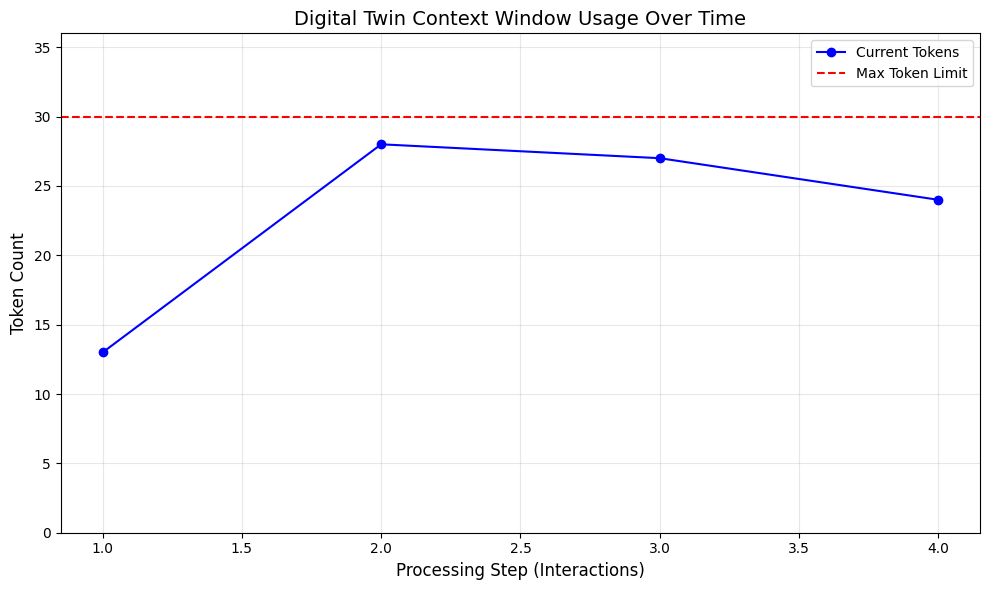

In [6]:
import logging
import re
import json
import matplotlib.pyplot as plt
from typing import List, Dict, Any, Union

# Set up standard logging for debugging and monitoring
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

class ProductionSystem:
    """
    Production-ready context window manager for a Digital Twin.

    This system handles conversational history, estimates token usage,
    enforces maximum token limits via a sliding window compression strategy,
    and tracks usage metrics for later visualisation.
    """

    def __init__(self, max_tokens: int = 50):
        # 1. Error Handling during initialisation
        if not isinstance(max_tokens, int) or max_tokens <= 0:
            logging.error("Failed to initialise: max_tokens must be a positive integer.")
            raise ValueError("max_tokens must be a positive integer.")

        self.max_tokens = max_tokens
        self.context: List[Dict[str, Any]] = []
        self.current_tokens: int = 0

        # 2. Tracking metrics for our visualisation
        self.history_metrics = {
            'processing_steps': [],
            'token_levels': [],
            'dropped_count': 0
        }
        self.step_counter = 0

        logging.info(f"ProductionSystem initialised successfully with max_tokens={self.max_tokens}")

    def _estimate_tokens(self, text: str) -> int:
        """Internal helper to estimate tokens using regular expressions."""
        if not isinstance(text, str):
            return 0
        tokens = re.findall(r'\b\w+\b|[.,!?;]', text)
        return len(tokens)

    def process(self, input_data: Union[str, Dict[str, Any]], role: str = "user") -> Dict[str, Any]:
        """
        Processes new input, updates the context window, and enforces limits.
        """
        logging.debug(f"Processing new input from role: {role}")
        self.step_counter += 1

        # 3. Comprehensive Error Handling & Input Validation
        try:
            if isinstance(input_data, str):
                if not input_data.strip():
                    raise ValueError("Input string cannot be empty.")
                content = input_data
            elif isinstance(input_data, dict):
                if 'content' not in input_data:
                    raise ValueError("Dictionary input must contain a 'content' key.")
                content = str(input_data['content'])
            else:
                raise TypeError(f"Unsupported input type: {type(input_data).__name__}")

            new_tokens = self._estimate_tokens(content)

            if new_tokens > self.max_tokens:
                raise ValueError("A single message exceeds the total context capacity.")

            # Create a structured message object
            message = {"role": role, "content": content, "tokens": new_tokens}

            # Add to state
            self.context.append(message)
            self.current_tokens += new_tokens

            # 4. Context Compression Strategy (Sliding Window)
            dropped_this_turn = 0
            while self.current_tokens > self.max_tokens:
                # Remove the oldest message
                removed_msg = self.context.pop(0)
                self.current_tokens -= removed_msg['tokens']
                dropped_this_turn += 1
                self.history_metrics['dropped_count'] += 1
                logging.warning(f"Context limit exceeded. Dropped oldest message ({removed_msg['tokens']} tokens).")

            # Record metrics for visualisation
            self.history_metrics['processing_steps'].append(self.step_counter)
            self.history_metrics['token_levels'].append(self.current_tokens)

            logging.info(f"Processed step {self.step_counter}. Current tokens: {self.current_tokens}/{self.max_tokens}")

            return {
                "status": "success",
                "active_messages": len(self.context),
                "current_tokens": self.current_tokens,
                "dropped_messages": dropped_this_turn
            }

        except Exception as e:
            # Catching and logging the error before raising it ensures we have a record
            logging.error(f"Error processing input: {str(e)}")
            raise

    def visualize_results(self):
        """
        Generates a chart tracking token usage over time to help debug
        and optimise our context window behaviour.
        """
        if not self.history_metrics['processing_steps']:
            logging.info("No data to visualise yet.")
            return

        fig, ax = plt.subplots(figsize=(10, 6))

        # Plot the token levels over time
        ax.plot(
            self.history_metrics['processing_steps'],
            self.history_metrics['token_levels'],
            marker='o',
            linestyle='-',
            color='b',
            label='Current Tokens'
        )

        # Draw a red dashed line showing our maximum limit
        ax.axhline(y=self.max_tokens, color='r', linestyle='--', label='Max Token Limit')

        # Formatting the chart
        ax.set_title('Digital Twin Context Window Usage Over Time', fontsize=14)
        ax.set_xlabel('Processing Step (Interactions)', fontsize=12)
        ax.set_ylabel('Token Count', fontsize=12)
        ax.set_ylim(0, self.max_tokens + (self.max_tokens * 0.2)) # Give the chart some headroom
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# --- Testing the Production System ---
print("\n--- Initialising Digital Twin System ---")
twin_system = ProductionSystem(max_tokens=30)

print("\n--- Simulating a Conversation ---")
# Simulating a back-and-forth that will eventually exceed the 30 token limit
try:
    twin_system.process("Hello, digital twin! Can you help me with a task?") # ~11 tokens
    twin_system.process("Of course! I am ready to assist you. What do you need?", role="assistant") # ~14 tokens
    twin_system.process("I need you to analyse some data from the factory floor.", role="user") # ~12 tokens. (Total ~37, will trigger compression)
    twin_system.process("Please provide the dataset and I will begin the analysis immediately.", role="assistant") # ~12 tokens

    # Passing an invalid input to test our error handling and logging
    # twin_system.process(12345)

except Exception as e:
    print(f"\nCaught an exception in main loop: {e}")

print("\n--- Generating Visualisation ---")
# This will render the matplotlib chart right inside your Colab notebook
twin_system.visualize_results()

---
## Summary & Key Takeaways

### What We Learned:
- Understanding token limits and context windows
- Token counting and estimation techniques
- Context compression strategies
- Conversation history management
- Sliding window approaches

### Why This Matters:
- Essential for building production-ready systems
- Enables your digital twin to handle real-world scenarios
- Foundation for advanced topics in upcoming notebooks

### Next Steps:
1. Complete all exercises in this notebook
2. Integrate concepts with your digital twin project
3. Test your implementation thoroughly
4. Move on to the next notebook in Week 2

## 🏆 Challenge Project

**Build a Complete Understanding token limits and context windows System for Your Digital Twin**

**Requirements**:
1. Apply all concepts from this notebook
2. Handle edge cases and errors gracefully
3. Include comprehensive testing
4. Create visualizations of your results
5. Document your implementation
6. Integrate with your existing digital twin code

**Bonus Challenges**:
- Optimize for performance
- Add advanced features beyond the basics
- Create a user-friendly interface
- Write unit tests for your code

E..
ERROR: test_add_message_and_compression (__main__.TestDigitalTwinContext.test_add_message_and_compression)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_4791/2506297437.py", line 127, in test_add_message_and_compression
    self.twin.add_message("assistant", "This is a very long response designed to push the token limit over the edge and force the sliding window to drop the first message.")
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_4791/2506297437.py", line 54, in add_message
    raise ValueError("Message is too large to fit alongside the system prompt.")
ValueError: Message is too large to fit alongside the system prompt.

----------------------------------------------------------------------
Ran 3 tests in 0.006s

FAILED (errors=1)


--- Running Unit Tests ---

--- Running Digital Twin Simulation ---

=== Digital Twin Active Context ===
⚙️ SYSTEM (14 tkns): You are an advanced digital twin overseeing Plant ...
👤 USER (9 tkns): What is the current temperature of Reactor 4?
🤖 ASSISTANT (15 tkns): Reactor 4 is currently operating at 180°C, which is within normal parameters.


=== Digital Twin Active Context ===
⚙️ SYSTEM (14 tkns): You are an advanced digital twin overseeing Plant ...
👤 USER (8 tkns): Are there any maintenance alerts for today?
🤖 ASSISTANT (14 tkns): Yes, valve 7 is scheduled for routine lubrication at 14:00 hours.


=== Digital Twin Active Context ===
⚙️ SYSTEM (14 tkns): You are an advanced digital twin overseeing Plant ...
🤖 ASSISTANT (14 tkns): Yes, valve 7 is scheduled for routine lubrication at 14:00 hours.
👤 USER (11 tkns): Understood. Please log that I have reviewed the schedule.

--- Generating Visualisation ---


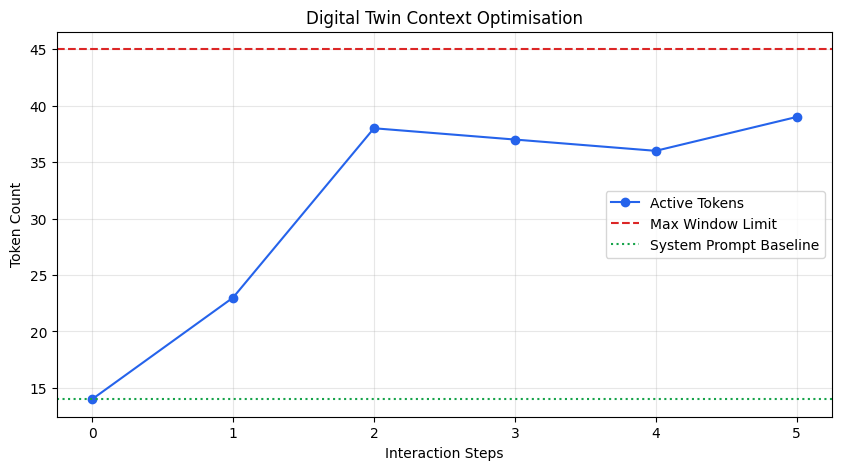

In [1]:
import logging
import re
import unittest
import matplotlib.pyplot as plt
from typing import List, Dict, Any

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

class DigitalTwinContextManager:
    """
    A robust context window manager for a Digital Twin.
    Maintains a persistent system prompt, enforces token limits via a sliding window,
    and tracks metrics for performance monitoring.
    """
    def __init__(self, system_prompt: str, max_tokens: int = 100):
        if not isinstance(max_tokens, int) or max_tokens <= 0:
            raise ValueError("max_tokens must be a positive integer.")
        if not isinstance(system_prompt, str) or not system_prompt.strip():
            raise ValueError("A valid system prompt string is required.")

        self.max_tokens = max_tokens
        self.system_prompt = system_prompt
        self.system_tokens = self._estimate_tokens(system_prompt)

        if self.system_tokens > (self.max_tokens * 0.5):
            logging.warning("System prompt consumes over 50% of the context window!")

        # Initialize state
        self.history: List[Dict[str, Any]] = []
        self.current_tokens: int = self.system_tokens

        # Metrics for visualisation
        self.metrics = {'steps': [0], 'tokens': [self.system_tokens]}
        self.step_count = 0

    def _estimate_tokens(self, text: str) -> int:
        """Estimates tokens using regex to capture words and punctuation."""
        return len(re.findall(r'\b\w+\b|[.,!?;]', str(text)))

    def add_message(self, role: str, content: str) -> bool:
        """
        Adds a new message to the context and triggers compression if necessary.
        Returns True if successful.
        """
        if role not in ["user", "assistant", "system"]:
            raise ValueError("Role must be 'user', 'assistant', or 'system'.")
        if not isinstance(content, str) or not content.strip():
            raise ValueError("Content must be a non-empty string.")

        msg_tokens = self._estimate_tokens(content)

        if msg_tokens + self.system_tokens > self.max_tokens:
            raise ValueError("Message is too large to fit alongside the system prompt.")

        self.history.append({"role": role, "content": content, "tokens": msg_tokens})
        self.current_tokens += msg_tokens
        self.step_count += 1

        self._compress_context()

        # Track metrics
        self.metrics['steps'].append(self.step_count)
        self.metrics['tokens'].append(self.current_tokens)
        return True

    def _compress_context(self):
        """
        Sliding window implementation that protects the system prompt.
        Drops the oldest conversational messages until we are under the limit.
        """
        dropped_count = 0
        while self.current_tokens > self.max_tokens and self.history:
            removed_msg = self.history.pop(0)
            self.current_tokens -= removed_msg['tokens']
            dropped_count += 1

        if dropped_count > 0:
            logging.info(f"Compressed context: Dropped {dropped_count} old messages.")

    def get_prompt_payload(self) -> List[Dict[str, str]]:
        """Generates the final payload ready to be sent to an LLM API."""
        payload = [{"role": "system", "content": self.system_prompt}]
        payload.extend([{"role": msg["role"], "content": msg["content"]} for msg in self.history])
        return payload

    def display_chat(self):
        """Bonus: User-friendly interface to view the current conversation state."""
        print("\n=== Digital Twin Active Context ===")
        print(f"⚙️ SYSTEM ({self.system_tokens} tkns): {self.system_prompt[:50]}...")
        for msg in self.history:
            icon = "👤" if msg['role'] == 'user' else "🤖"
            print(f"{icon} {msg['role'].upper()} ({msg['tokens']} tkns): {msg['content']}")
        print("===================================\n")

    def visualise_usage(self):
        """Plots token usage over time to monitor the sliding window."""
        plt.figure(figsize=(10, 5))
        plt.plot(self.metrics['steps'], self.metrics['tokens'], marker='o', label='Active Tokens', color='#2563eb')
        plt.axhline(y=self.max_tokens, color='#dc2626', linestyle='--', label='Max Window Limit')
        plt.axhline(y=self.system_tokens, color='#16a34a', linestyle=':', label='System Prompt Baseline')

        plt.title('Digital Twin Context Optimisation')
        plt.xlabel('Interaction Steps')
        plt.ylabel('Token Count')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# ==========================================
# Bonus Challenge: Unit Testing Suite
# ==========================================
class TestDigitalTwinContext(unittest.TestCase):
    def setUp(self):
        self.twin = DigitalTwinContextManager("You are a helpful factory digital twin.", max_tokens=30)

    def test_initialisation(self):
        self.assertEqual(self.twin.max_tokens, 30)
        self.assertTrue(self.twin.system_tokens > 0)

    def test_add_message_and_compression(self):
        # Add small messages
        self.twin.add_message("user", "Hello there.")
        self.assertEqual(len(self.twin.history), 1)

        # Force compression by adding a large message
        self.twin.add_message("assistant", "This is a very long response designed to push the token limit over the edge and force the sliding window to drop the first message.")

        # The first message ("Hello there") should have been dropped to make room
        self.assertEqual(len(self.twin.history), 1)
        self.assertEqual(self.twin.history[0]['role'], "assistant")

    def test_invalid_inputs(self):
        with self.assertRaises(ValueError):
            self.twin.add_message("invalid_role", "Test")
        with self.assertRaises(ValueError):
            self.twin.add_message("user", "") # Empty string

# ==========================================
# Execution and Demonstration
# ==========================================
if __name__ == '__main__':
    print("--- Running Unit Tests ---")
    # We use argv=['first-arg-is-ignored'] to run unittest nicely inside Jupyter/Colab
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

    print("\n--- Running Digital Twin Simulation ---")
    my_twin = DigitalTwinContextManager(
        system_prompt="You are an advanced digital twin overseeing Plant Alpha. Always reply concisely.",
        max_tokens=45
    )

    # Simulate a conversation
    my_twin.add_message("user", "What is the current temperature of Reactor 4?")
    my_twin.add_message("assistant", "Reactor 4 is currently operating at 180°C, which is within normal parameters.")
    my_twin.display_chat()

    my_twin.add_message("user", "Are there any maintenance alerts for today?")
    my_twin.add_message("assistant", "Yes, valve 7 is scheduled for routine lubrication at 14:00 hours.")
    my_twin.display_chat() # You will see earlier messages drop off here

    my_twin.add_message("user", "Understood. Please log that I have reviewed the schedule.")
    my_twin.display_chat()

    print("--- Generating Visualisation ---")
    my_twin.visualise_usage()